# MODEL — Initial Baselines

First pass at predicting `log_aav_cap_share` (AAV as a share of the signing-season cap, logged).
This notebook fits **three baselines** (real models will be done later):

1. **Global median**: the same prediction for every deal.
2. **Segment median - `years_pro`**: a train median per experience bucket.
3. **Segment median — `prior_mpg`**: a train median per prior-season minutes bucket.

These set the floor any real model must beat, and the segment baselines show
whether a single player-quality split explains meaningful variance. Every statistic is fit on
train rows only. `val` is the headline split, `test` stays hold-out.

Outputs: `data/model/results.csv` (metrics) and `data/model/predictions_baselines.csv`.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
PREP_CSV = PROJECT_ROOT / "data" / "model" / "prep.csv"
RESULTS_CSV = PROJECT_ROOT / "data" / "model" / "results.csv"
PRED_CSV = PROJECT_ROOT / "data" / "model" / "predictions_baselines.csv"

prep = pd.read_csv(PREP_CSV)
TARGET = "log_aav_cap_share"
y = prep[TARGET]

masks = {s: prep["split"].eq(s) for s in ("train", "val", "test")}
print("split sizes:", {s: int(m.sum()) for s, m in masks.items()})
print()
print("target describe (train):")
print(y[masks["train"]].describe().round(3).to_string())

split sizes: {'train': 906, 'val': 216, 'test': 242}

target describe (train):
count    906.000
mean      -2.969
std        1.152
min       -6.148
25%       -4.102
50%       -2.917
75%       -2.019
max       -0.832


## Evaluation

Two views of error, both shared by every future model:

- **Log scale** (`rmse`, `mae`, `r2`) on `log_aav_cap_share` directly. This is the natural scale
  for the target- the distribution is symmetric here and errors on star contracts aren't
  automatically weighted above role-player errors.
- **Dollar scale** (`rmse_dollars`, `mae_dollars`) on `exp(y)` vs `exp(pred)`, (**AAV in $M**).
  Big deals dominate these numbers, so they gauge real-money accuracy rather than ranking power.

In [2]:
from metrics import evaluate, rmse, mae, r2

## Baseline A — global median

One number for every deal: the **median** `log_aav_cap_share` on **train**. It ignores
everything about a deal, so its error is the "no information" reference point for everything else.

In [3]:
g_median = float(y[masks["train"]].median())
pred = pd.Series(g_median, index=y.index)
print(f"global train median log_aav_cap_share = {g_median:.4f}  ->  exp = {np.exp(g_median):.4f} of cap")

results = []


def register(model, description, fit_params, pred_series):
    for split, m in masks.items():
        row = {"model": model, "description": description, "fit_params": fit_params,
               "split": split}
        row.update(evaluate(y[m], pred_series[m]))
        results.append(row)
    return pred_series


register("global_median", "median of the train target for every deal", f"median={g_median:.4f}", pred)

global train median log_aav_cap_share = -2.9167  ->  exp = 0.0541 of cap


0      -2.916671
1      -2.916671
2      -2.916671
3      -2.916671
4      -2.916671
          ...   
1359   -2.916671
1360   -2.916671
1361   -2.916671
1362   -2.916671
1363   -2.916671
Length: 1364, dtype: float64

## Baseline B — segment median by `years_pro`

Players aren't interchangeable: a rookie and a 9-year veteran sit on different salary tracks.
Split the train set into experience buckets and predict each deal with its bucket's **train
median**:

<table>
<tr><th>bucket</th><th>meaning</th><th align="right">train n</th></tr>
<tr><td>0</td><td>rookie</td><td align="right">191</td></tr>
<tr><td>1-3</td><td>early</td><td align="right">194</td></tr>
<tr><td>4-6</td><td>mid</td><td align="right">179</td></tr>
<tr><td>7-9</td><td>prime</td><td align="right">122</td></tr>
<tr><td>10+</td><td>veteran</td><td align="right">103</td></tr>
</table>

The 7–9 "prime" bucket carries the highest median target, exactly the shape a market model
should capture. Any bucket absent from train falls back to the global median.

In [4]:
def bucket_years_pro(s):
    return pd.cut(s, bins=[-1, 0, 3, 6, 9, np.inf],
                  labels=["0", "1-3", "4-6", "7-9", "10+"], right=True)

tr_b = bucket_years_pro(prep.loc[masks["train"], "years_pro"])
print("train bucket counts:")
print(tr_b.value_counts().sort_index().to_string())

bucket_med = y[masks["train"]].groupby(tr_b).median()
fit = {k: float(v) for k, v in bucket_med.items()}
print("\ntrain bucket medians:", {k: round(v, 4) for k, v in fit.items()})

b = bucket_years_pro(prep["years_pro"])
pred_b = b.map(fit).fillna(g_median)
register("segment_median_years_pro", "train median per years_pro bucket (0,1-3,4-6,7-9,10+)",
         json.dumps(fit), pred_b)

train bucket counts:
years_pro
0      235
1-3    210
4-6    200
7-9    135
10+    126

train bucket medians: {'0': -4.3326, '1-3': -2.8075, '4-6': -2.5673, '7-9': -1.9608, '10+': -2.4042}


0      -4.332629
1      -2.567277
2      -2.807508
3      -2.567277
4      -2.567277
          ...   
1359   -4.332629
1360   -4.332629
1361   -2.807508
1362   -2.567277
1363   -1.960817
Name: years_pro, Length: 1364, dtype: category
Categories (5, float64): [-4.332629 < -2.807508 < -2.567277 < -1.960817 < -2.404246]

## Baseline C — segment median by `prior_mpg`

Prior-season minutes are a strong, simple quality signal. Buckets:

<table>
<tr><th>bucket</th><th>meaning</th><th align="right">train n</th></tr>
<tr><td>&lt;10</td><td>deep bench / out of rotation</td><td align="right">24</td></tr>
<tr><td>10-20</td><td>rotation</td><td align="right">177</td></tr>
<tr><td>20-30</td><td>starter-level</td><td align="right">431</td></tr>
<tr><td>30+</td><td>stars / iron men</td><td align="right">157</td></tr>
</table>

The train median target rises monotonically across buckets (−4.13 → −1.38). Rows with no prior
season (239, `has_prior_stats=0`) were median-imputed to 24.6 mpg, so they land in `20–30`; the
`has_prior_stats` flag stays available to future models.

In [5]:
def bucket_mpg(s):
    return pd.cut(s, bins=[-1, 10, 20, 30, np.inf],
                  labels=["<10", "10-20", "20-30", "30+"], right=True)

tr_m = bucket_mpg(prep.loc[masks["train"], "prior_mpg"])
print("train bucket counts:")
print(tr_m.value_counts().sort_index().to_string())

bucket_med_m = y[masks["train"]].groupby(tr_m).median()
fit_m = {k: float(v) for k, v in bucket_med_m.items()}
print("\ntrain bucket medians:", {k: round(v, 4) for k, v in fit_m.items()})

b_m = bucket_mpg(prep["prior_mpg"])
pred_m = b_m.map(fit_m).fillna(g_median)
register("segment_median_prior_mpg", "train median per prior_mpg bucket (<10,10-20,20-30,30+)",
         json.dumps(fit_m), pred_m)

train bucket counts:
prior_mpg
<10       27
10-20    192
20-30    499
30+      188

train bucket medians: {'<10': -4.1316, '10-20': -3.5251, '20-30': -3.1499, '30+': -1.4097}


0      -3.149883
1      -3.149883
2      -3.525075
3      -3.525075
4      -3.525075
          ...   
1359   -3.149883
1360   -3.149883
1361   -3.525075
1362   -3.149883
1363   -3.149883
Name: prior_mpg, Length: 1364, dtype: category
Categories (4, float64): [-4.131628 < -3.525075 < -3.149883 < -1.409717]

## Results

Long-format table — one row per model × split. `val` is the headline; `test` is held out and
reported only for context.

In [6]:
res = pd.DataFrame(results)
res.to_csv(RESULTS_CSV, index=False)
print("wrote", RESULTS_CSV)
print()
res.round(3).to_string(index=False)

wrote ../data/model/results.csv



'                   model                                             description                                                                                           fit_params split  rmse   mae     r2  rmse_dollars  mae_dollars\n           global_median               median of the train target for every deal                                                                                       median=-2.9167 train 1.153 1.007 -0.002         0.105        0.071\n           global_median               median of the train target for every deal                                                                                       median=-2.9167   val 1.028 0.880 -0.000         0.106        0.066\n           global_median               median of the train target for every deal                                                                                       median=-2.9167  test 0.978 0.819 -0.007         0.104        0.065\nsegment_median_years_pro   train median per years_pro bucke

## Predictions

Predicted `log_aav_cap_share` for every row, one column per baseline — saved so later notebooks
can reuse or compare them (e.g., residual analysis) without re-fitting.

In [7]:
preds = pd.DataFrame({
    "player_id": prep["player_id"],
    "player_name": prep["player_name"],
    "split": prep["split"],
    "log_aav_cap_share": y,
    "global_median": pd.Series(g_median, index=y.index),
    "segment_years_pro": pred_b,
    "segment_prior_mpg": pred_m,
})
preds.to_csv(PRED_CSV, index=False)
print("wrote", PRED_CSV, preds.shape)

wrote ../data/model/predictions_baselines.csv (1364, 7)


## Comparison

Val-set log-RMSE / log-MAE and $RMSE across the three baselines. A future model must beat the
segment baselines on `val`, not just the global median.

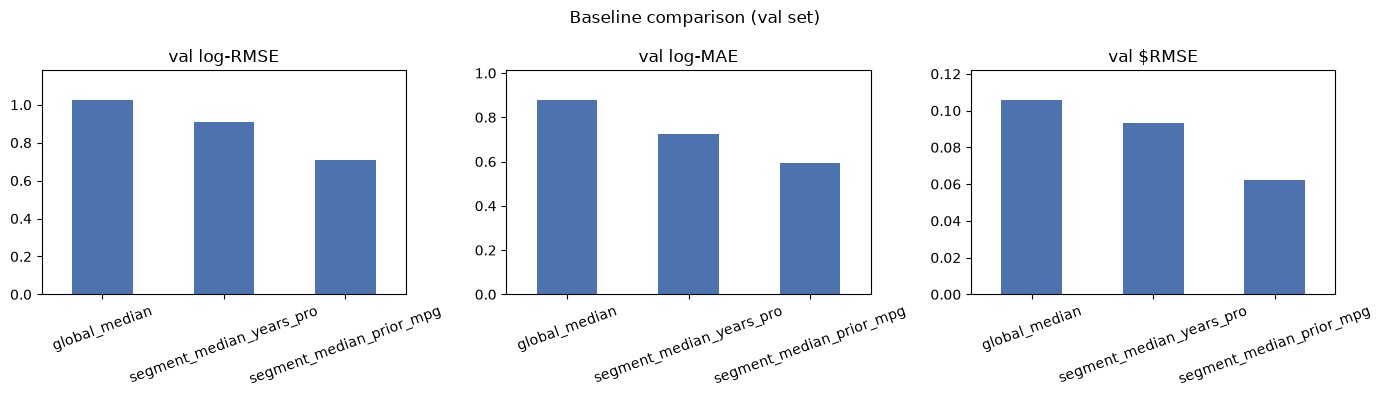

In [8]:
val = res[res["split"] == "val"].set_index("model").loc[
    ["global_median", "segment_median_years_pro", "segment_median_prior_mpg"]
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in (
    (axes[0], "rmse", "val log-RMSE"),
    (axes[1], "mae", "val log-MAE"),
    (axes[2], "rmse_dollars", "val $RMSE"),
):
    val[col].plot.bar(ax=ax, color="#4C72B0")
    ax.set_title(title)
    ax.set_ylim(0, val[col].max() * 1.15)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Baseline comparison (val set)")
fig.tight_layout()
plt.show()

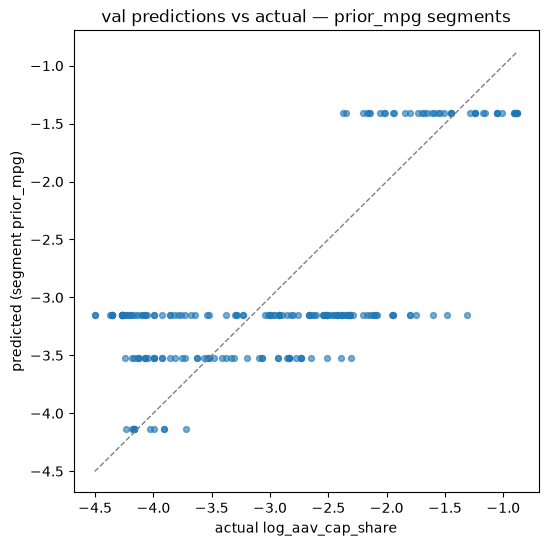

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
v = masks["val"]
ax.scatter(y[v], pred_m[v], s=18, alpha=0.6)
lo = min(y[v].min(), pred_m[v].min())
hi = max(y[v].max(), pred_m[v].max())
ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1)
ax.set_xlabel("actual log_aav_cap_share")
ax.set_ylabel("predicted (segment prior_mpg)")
ax.set_title("val predictions vs actual — prior_mpg segments")
plt.show()

## Takeaways

- The global median is the floor: its `val` error is the "no information" reference.
- Both segment baselines beat it, so `years_pro` and especially `prior_mpg` carry real pay
  signal. `prior_mpg` is the current model to beat.
- Next models (linear / regularized / trees) will reuse `evaluate()` and the `results` registry,
  appending to `data/model/results.csv`.
- Every statistic was fit on train only, no future information leaked into any baseline.